# Try WGF on MgkPro with New Measurements.

## Prepare Notebook.

In [1]:
%reload_ext autoreload
%autoreload 2

### Import Libraries.

In [2]:
import os
import sys

import hydra
import matplotlib.pyplot as plt
import numpy as np
import omegaconf
import scanpy as sc
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import torch

import scopt
import sc_exp_design


### Import Additional Modules.

In [3]:
sys.path.insert(0, "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/shared_utils")
from experiment_utils import (
    get_forward_model,
    generate_with_condition,
    get_transformed_data,
    get_loss_fn,
    get_target_dict,
)
from inverse_utils import (
    map_df,
    loss_fn_factory,
)

### Read Configurations.

In [24]:
with hydra.initialize(
    config_path="../../loss_guidance/config"
):
    config = hydra.compose(
        config_name="run_inverse_constrained",
        overrides=[
            "paths=bloodplus_fm",
            "sampling.query_pure_cell_types=True",
            "sampling.mask_gradients=False",
            "sampling.target_cell_type=GMP-Neutro",
            # "sampling.target_cell_type=CyclingPro1",
            # "sampling.target_cell_type=HSCs",
            # "sampling.target_cell_type=EryPro",
            # "sampling.target_cell_type=late_MgkPro",
            "sampling.N=100",
            "loss_guidance.num_forward_pass_per_sample=100",
            # "paths.perturbation_prediction_path=/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/conditional_model/flow_matching/2026-04-02_14-16-39/neat-river-1_FlowMatching.pkl",
            "paths.perturbation_prediction_path=/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/conditional_model/flow_matching/2026-04-02_14-16-39/wild-moon-1_FlowMatching.pkl",
            "forward_model.num_time_steps=20",
        ]
    )

/tmp/ipykernel_1432583/1676731704.py:1: UserWarning: 
The version_base parameter is not specified.
Please specify a compatibility version level, or None.
Will assume defaults for version 1.1
  with hydra.initialize(


## Prepare Loss Function.

### Load Forward Model.

In [5]:
forward_model, (
    _,
    target_prediction_model
) = get_forward_model(config)
forward_model.target_prediction_model.resc_model["model"].eval()
forward_model.forward_model.velocity_field.eval()
print(forward_model.target_prediction_model.resc_model["model"])
print(forward_model.forward_model.velocity_field)

PerturbationApproximatePosterior(
  (pert_approximate_posterior): ModuleDict(
    (encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=26, out_features=128, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.0, inplace=False)
        )
        (1): Sequential(
          (0): Linear(in_features=128, out_features=128, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.0, inplace=False)
        )
        (2): Sequential(
          (0): Linear(in_features=128, out_features=64, bias=True)
          (1): Identity()
        )
      )
    )
    (cell_type): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=64, out_features=24, bias=True)
          (1): Identity()
        )
      )
    )
  )
)
NeuralVelocityField(
  (vf_modules): ModuleDict(
    (x_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=26, out_features=256, bias=True)

### Prepare Label Encoder for Cell Types.

In [6]:
ct_le = LabelEncoder()
ct_values = target_prediction_model.train_data.adata.obs["cell_type"].values
ct_le.fit(ct_values)
classes = ct_le.classes_.tolist()


### Prepare Loss Function.

In [25]:
loss_fns = get_loss_fn(config)

target = get_target_dict(
    config,
    classes,
    forward_model.forward_model.device
)

# non_linearity = torch.nn.Identity()
non_linearity = torch.nn.ReLU()

compute_loss, noise = loss_fn_factory(
    loss_fns,
    config,
    target,
    non_linearity,
    forward_model,
)

### Load Prior Models.

In [10]:
# define paths to model checkpoints
prior_cfm_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/prior/flow_matching/2026-03-24_13-24-10/divine-grass-17_FlowMatchingWithScore.pkl"
prior_fm_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/prior/flow_map/2026-03-24_16-31-51/swept-morning-20_FlowMap.pkl"

# initialize prior models
prior_cfm = sc_exp_design.models.FlowMatchingWithScore.load(prior_cfm_path)
prior_fm = sc_exp_design.models.FlowMap.load(prior_fm_path)
prior_cfm.velocity_field.eval()
prior_fm.flow_map.eval()

# show modules
print(prior_cfm.velocity_field)
print(prior_fm.flow_map)

NeuralVelocityFieldWithScore(
  (vf_modules): ModuleDict(
    (x_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=12, out_features=256, bias=True)
          (1): ELU(alpha=1.0)
        )
        (1): Sequential(
          (0): Linear(in_features=256, out_features=16, bias=True)
          (1): Identity()
        )
      )
    )
    (time_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=256, out_features=256, bias=True)
          (1): ELU(alpha=1.0)
        )
        (1): Sequential(
          (0): Linear(in_features=256, out_features=8, bias=True)
          (1): Identity()
        )
      )
    )
    (resnet_blocks): ModuleList(
      (0-2): 3 x ResnetBlock(
        (net1): Sequential(
          (0): SiLU()
          (1): Linear(in_features=16, out_features=16, bias=True)
        )
        (cond_proj): Sequential(
          (0): SiLU()
          (1): Linear(in_features=8, out_fe

### Patch silu module.

In [11]:
# 1. Define the AD-safe SiLU
class SafeSiLU(torch.nn.Module):
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x * torch.sigmoid(x)

# 2. Define the recursive patch function
def replace_silu_with_safe_silu(model: torch.nn.Module) -> None:
    for name, module in model.named_children():
        if isinstance(module, torch.nn.SiLU):
            setattr(model, name, SafeSiLU())
        else:
            # Recursively apply to sub-modules
            replace_silu_with_safe_silu(module)

# 3. Apply the patch to your specific models
velocity_field_net = prior_cfm.velocity_field
flow_map_net = prior_fm.flow_map

replace_silu_with_safe_silu(velocity_field_net)
replace_silu_with_safe_silu(flow_map_net)

print("Successfully replaced all SiLU activations with SafeSiLU.")

Successfully replaced all SiLU activations with SafeSiLU.


## LGF.

### Sample From Posterior.

In [26]:
# prepare time rescaling and posterior sampler
lgf = scopt.methods.LossGuidedFlow(
    compute_loss,
    prior_cfm,
    flow_map=prior_fm,
)

# optimization params
num_opt_samples = 100
num_time_steps = 100
solver_kwargs = {
    "method": "euler",
    "atol": 1e-5,
    "rtol": 1e-5,
}

# sample
lgf_sampling_traj = lgf.sample(
    num_opt_samples,
    num_time_steps=num_time_steps,
    solver_kwargs=solver_kwargs,
).detach().cpu().numpy()
lgf_opt_samples = lgf_sampling_traj[-1]
torch.cuda.empty_cache()

## WGF.

### Sample From Posterior.

In [27]:
# set sampler parameters
estimator = "hutch-rademacher"
gamma = 1.0
horizon = 1.0

# prepare time rescaling and posterior sampler
# time_warping = scopt.schedulers.CosineWarping(horizon=horizon)
time_warping = scopt.schedulers.LinearWarping()

wgf = scopt.methods.ULAGuidedFlow(
    compute_loss,
    prior_cfm,
    flow_map=prior_fm,
    scheduler=time_warping,
    gamma=gamma,
    estimator=estimator,
    use_flow_map_score_estimator=False,
)

#  optimization params
num_opt_samples = 100
num_time_steps = 100
solver_kwargs = {
    "method": "euler",
    "atol": 1e-5,
    "rtol": 1e-5,
}

wgf_sampling_traj = wgf.sample(
    num_opt_samples,
    num_time_steps=num_time_steps,
    solver_kwargs=solver_kwargs,
).detach().cpu().numpy()
wgf_opt_samples = wgf_sampling_traj[-1]
torch.cuda.empty_cache()

## Langevin.

In [28]:
# set sampler parameters
estimator = "hutch-rademacher"
gamma = 1.0
horizon = 1.0

# prepare time rescaling and posterior sampler
# time_warping = scopt.schedulers.CosineWarping(horizon=horizon)
time_warping = scopt.schedulers.LinearWarping()

lwgf = scopt.methods.ULAGuidedFlow(
    compute_loss,
    prior_cfm,
    flow_map=prior_fm,
    scheduler=time_warping,
    gamma=gamma,
    estimator=estimator,
    use_flow_map_score_estimator=False,
    use_langevin=True,
)

#  optimization params
num_opt_samples = 100
num_time_steps = 100
solver_kwargs = {
    "method": "euler",
    "atol": 1e-5,
    "rtol": 1e-5,
}

lwgf_sampling_traj = lwgf.sample(
    num_opt_samples,
    num_time_steps=num_time_steps,
    solver_kwargs=solver_kwargs,
).detach().cpu().numpy()
lwgf_opt_samples = lwgf_sampling_traj[-1]
torch.cuda.empty_cache()

## Visualize Samples.

Text(0.5, 1.02, 'L-WGF')

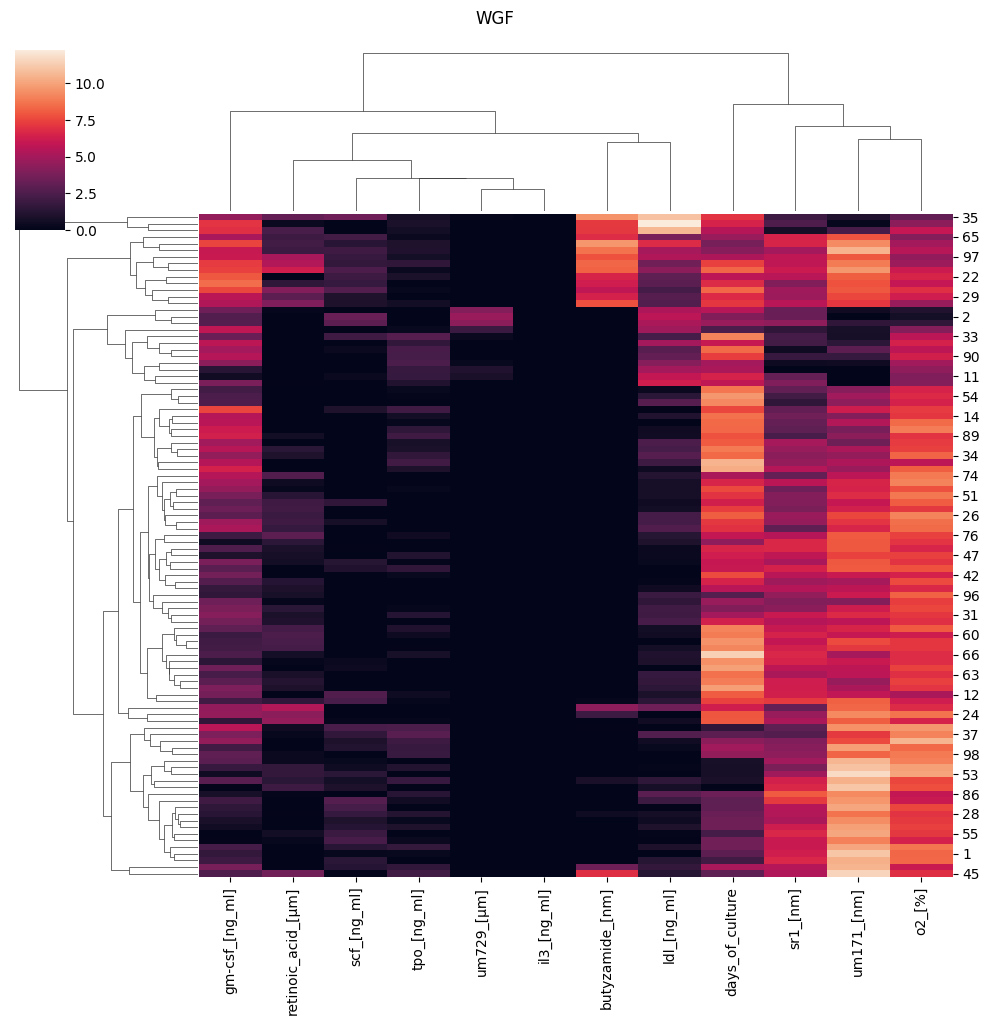

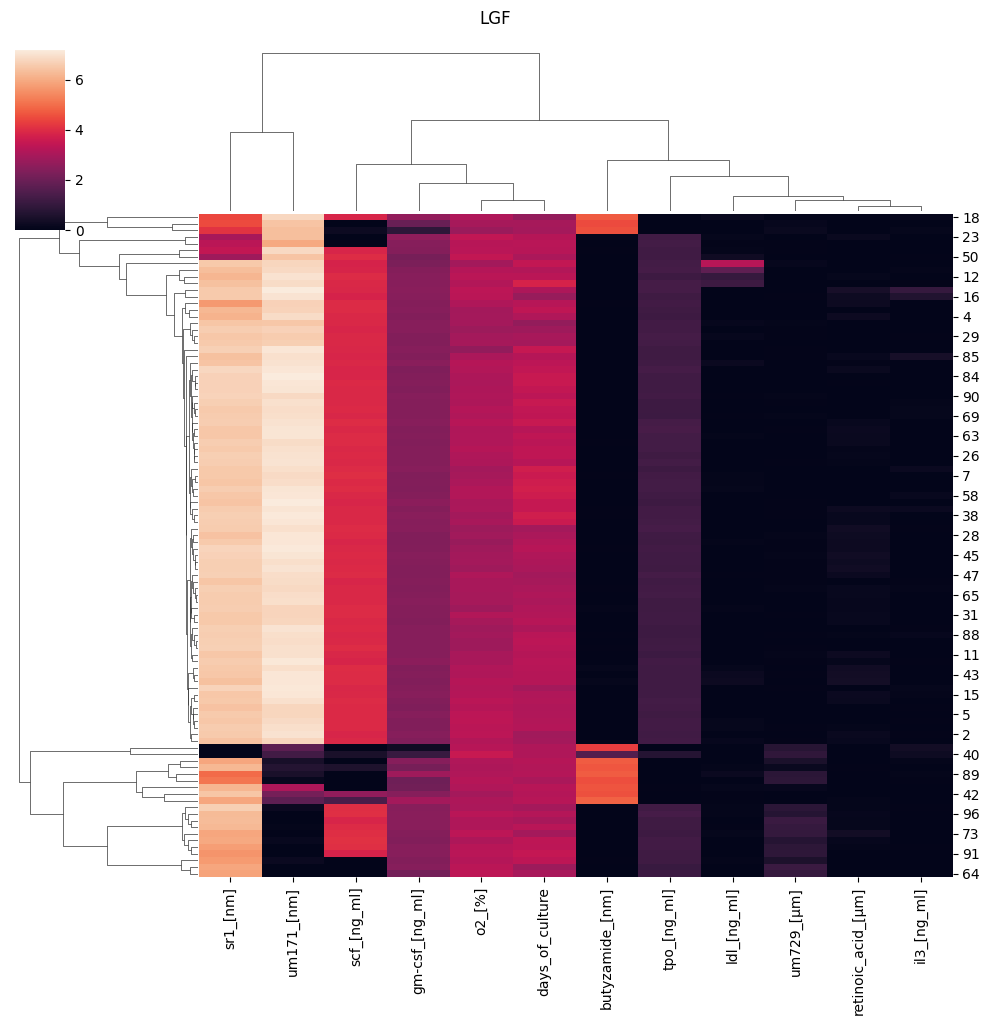

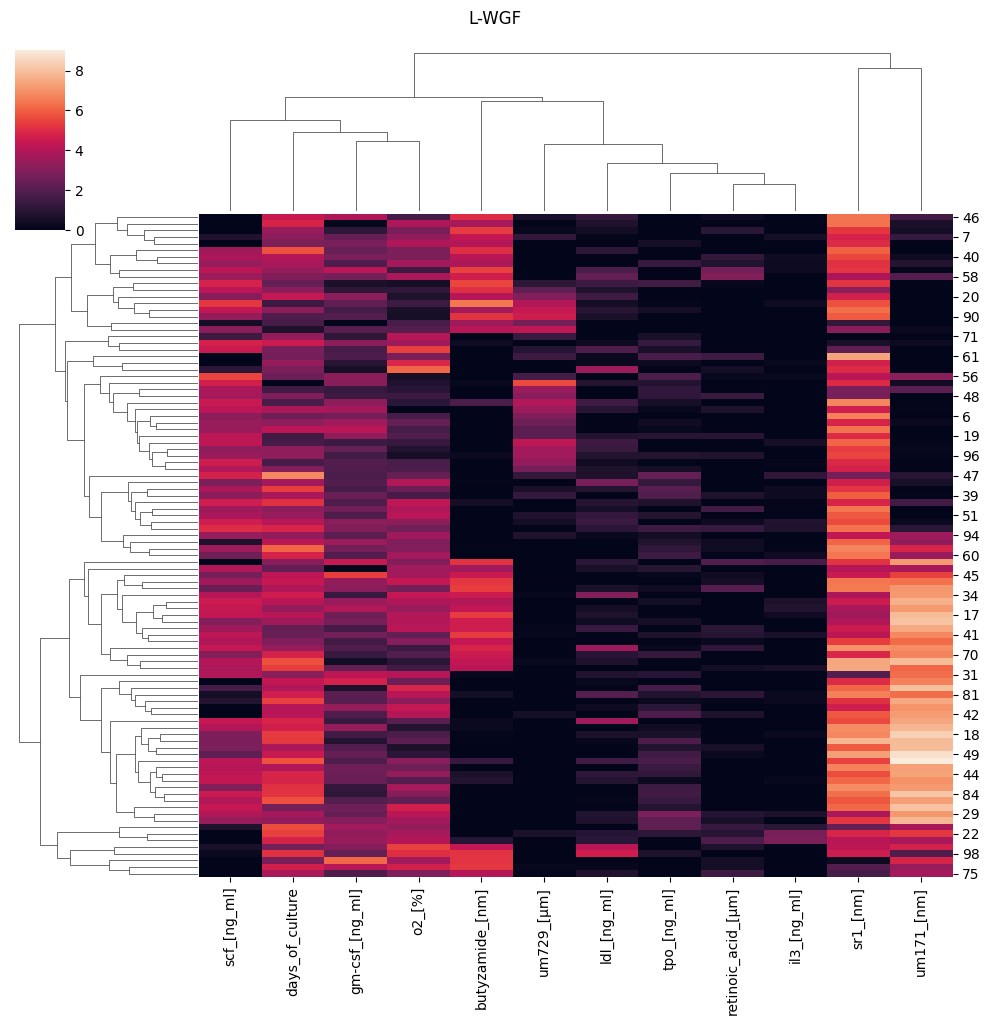

In [29]:
# WGF
g_wgf = sns.clustermap(np.maximum(wgf_opt_samples, 0.0), xticklabels=config.annotation.protocol_columns)
g_wgf.fig.suptitle("WGF", y=1.02)  # y > 1 pushes the title slightly above the dendrogram

# LGF
g_lgf = sns.clustermap(np.maximum(lgf_opt_samples, 0.0), xticklabels=config.annotation.protocol_columns)
g_lgf.fig.suptitle("LGF", y=1.02)

# L-WGF
g_lwgf = sns.clustermap(np.maximum(lwgf_opt_samples, 0.0), xticklabels=config.annotation.protocol_columns)
g_lwgf.fig.suptitle("L-WGF", y=1.02)

<Axes: title={'center': 'L-WGF Loss Guidance'}>

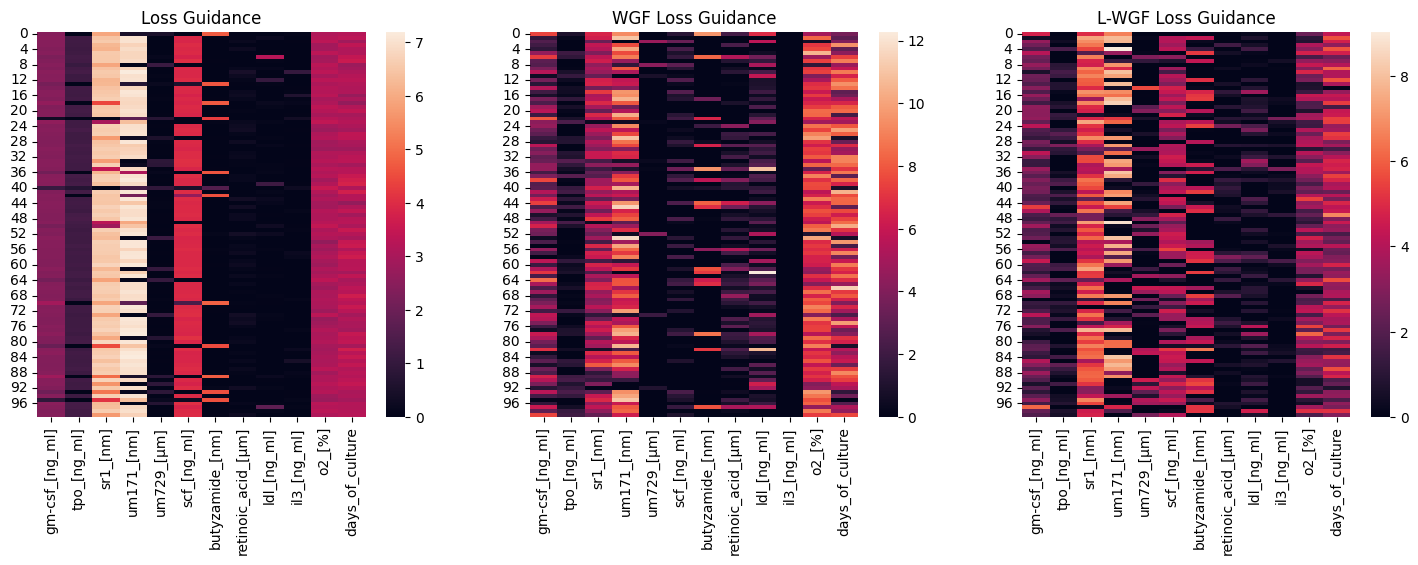

In [30]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

ax[0].set_title("Loss Guidance")
sns.heatmap(np.maximum(lgf_opt_samples, 0.0), ax=ax[0], xticklabels=config.annotation.protocol_columns)

ax[1].set_title("WGF Loss Guidance")
sns.heatmap(np.maximum(wgf_opt_samples, 0.0), ax=ax[1], xticklabels=config.annotation.protocol_columns)

ax[2].set_title("L-WGF Loss Guidance")
sns.heatmap(np.maximum(lwgf_opt_samples, 0.0), ax=ax[2], xticklabels=config.annotation.protocol_columns)

## Compute Loss.

In [31]:
lwgf_loss = compute_loss(torch.from_numpy(lwgf_sampling_traj[-1]).to(torch.float).to(prior_cfm.device))
wgf_loss = compute_loss(torch.from_numpy(wgf_sampling_traj[-1]).to(torch.float).to(prior_cfm.device))
lgf_loss = compute_loss(torch.from_numpy(lgf_sampling_traj[-1]).to(torch.float).to(prior_cfm.device))

## plot Loss.

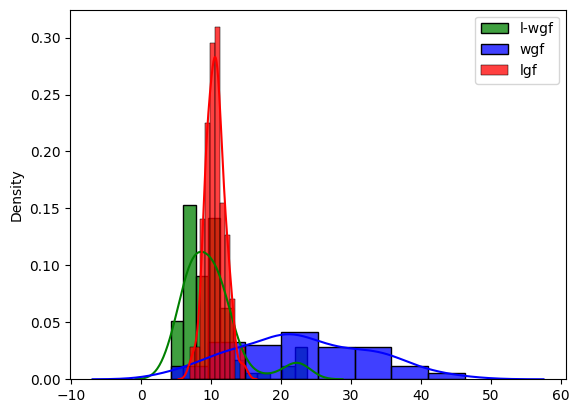

In [32]:
sns.histplot(lwgf_loss.detach().cpu(), stat="density", color="green", label="l-wgf")
sns.kdeplot(lwgf_loss.detach().cpu(), color="green")

sns.histplot(wgf_loss.detach().cpu(), stat="density", color="blue", label="wgf")
sns.kdeplot(wgf_loss.detach().cpu(), color="blue")

sns.histplot(lgf_loss.detach().cpu(), stat="density", color="red", label="lgf")
sns.kdeplot(lgf_loss.detach().cpu(), color="red")

plt.legend()


## Query Forward Model.

In [33]:
num_sample_fwd = 350

print("wgf")
wgf_gen = generate_with_condition(
    wgf_opt_samples,
    forward_model,
    num_time_steps,
    solver_kwargs,
    ct_le,
    num_samples=num_sample_fwd,
    # noise=noise,
    logger=None,
    n_scatter_feats=6,
)

print("l-wgf")
lwgf_gen = generate_with_condition(
    lwgf_opt_samples,
    forward_model,
    num_time_steps,
    solver_kwargs,
    ct_le,
    num_samples=num_sample_fwd,
    # noise=noise,
    logger=None,
    n_scatter_feats=6,
)

print("lgf")
lgf_gen = generate_with_condition(
    lgf_opt_samples,
    forward_model,
    num_time_steps,
    solver_kwargs,
    ct_le,
    num_samples=num_sample_fwd,
    # noise=noise,
    logger=None,
    n_scatter_feats=6,
)

wgf
l-wgf
lgf


Text(0.5, 1.02, 'L-WGF')

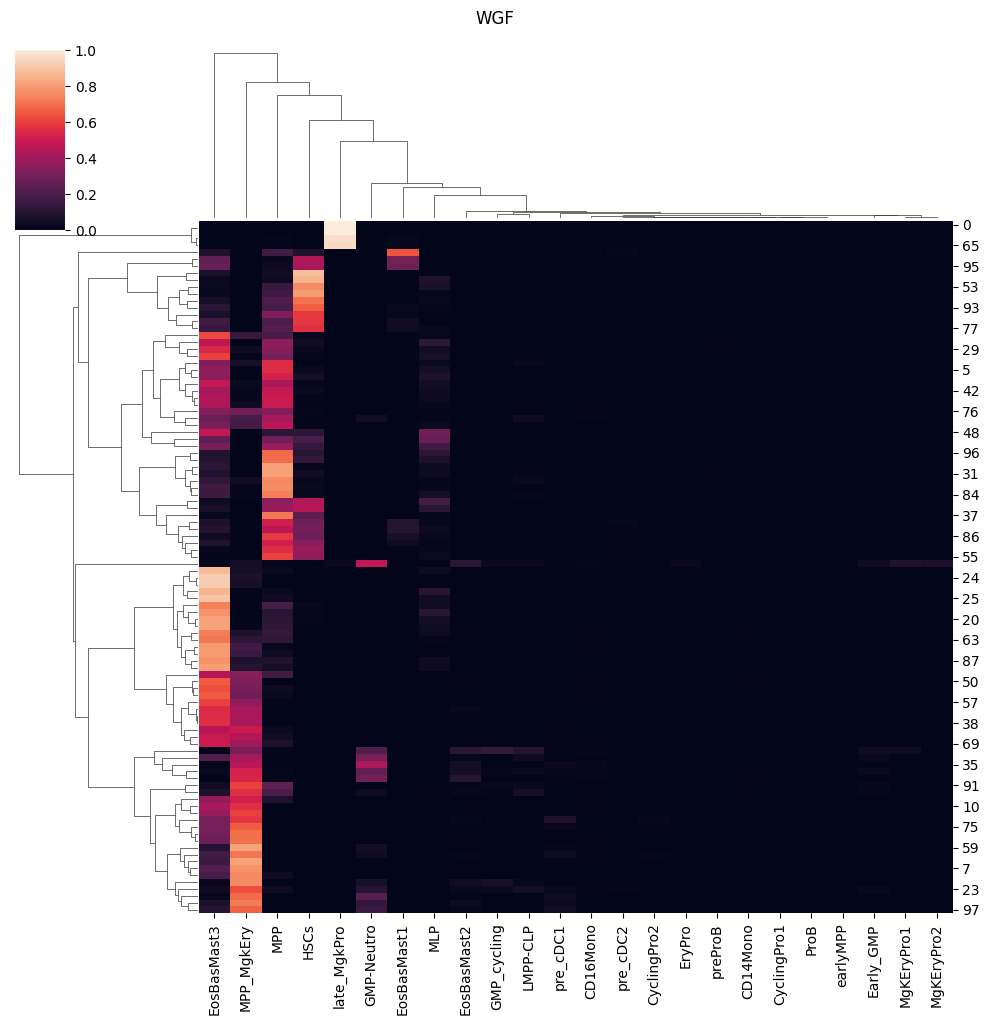

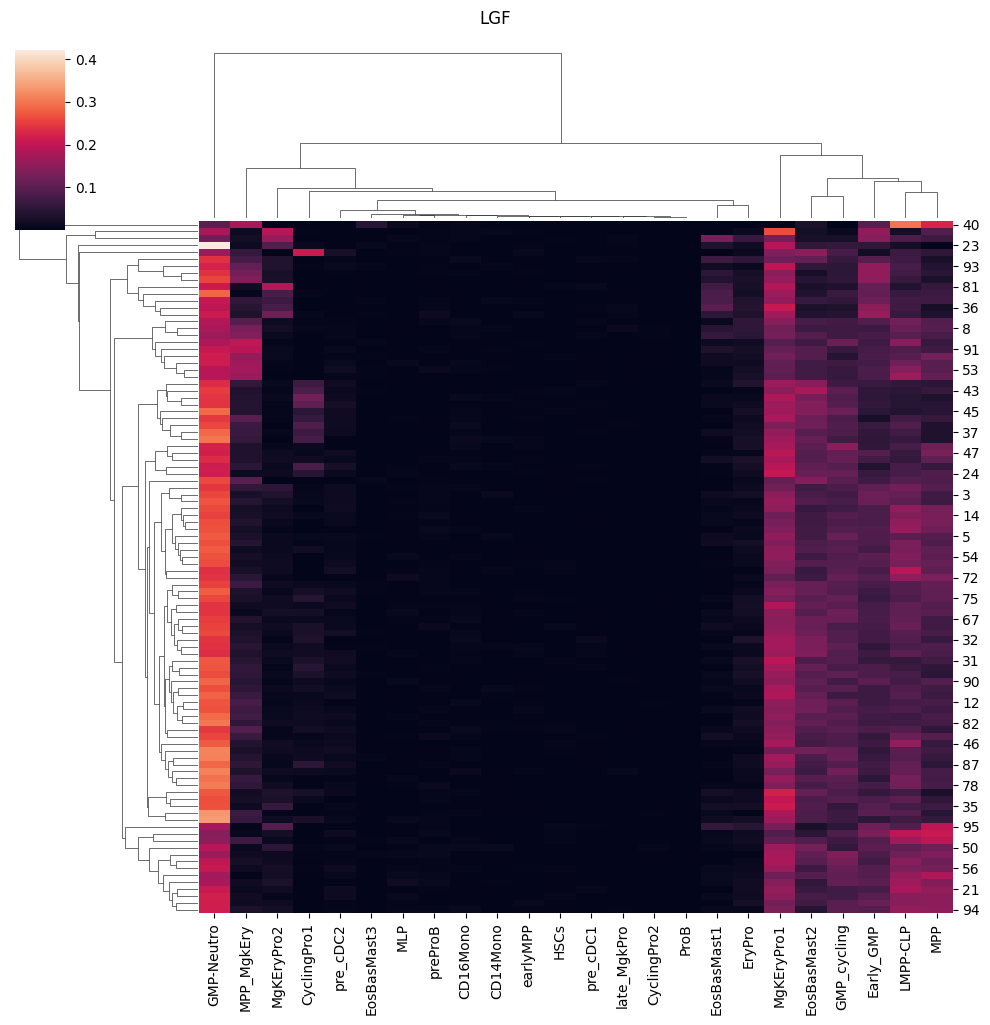

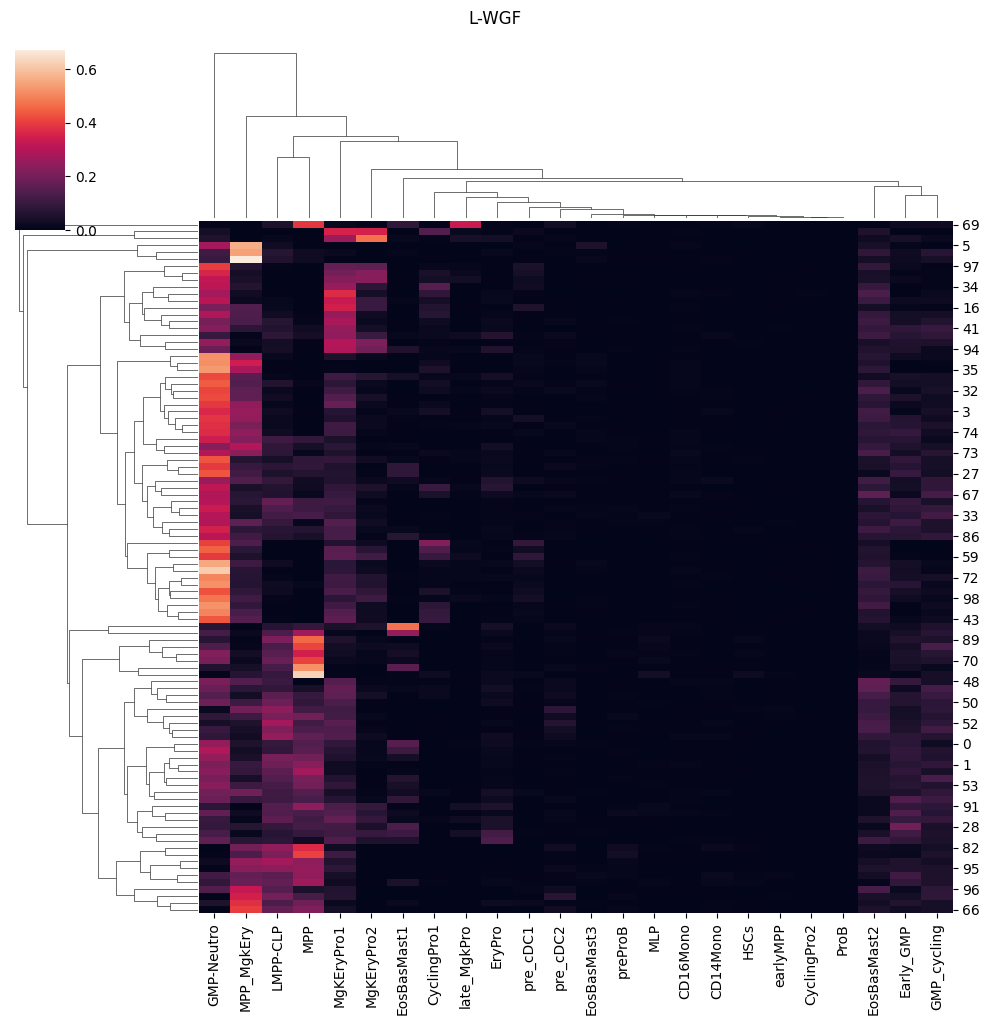

In [34]:
# WGF
g_wgf = sns.clustermap(wgf_gen["ct_probs"].mean(0), xticklabels=ct_le.classes_)
g_wgf.fig.suptitle("WGF", y=1.02)  # y > 1 pushes the title slightly above the dendrogram

# LGF
g_lgf = sns.clustermap(lgf_gen["ct_probs"].mean(0), xticklabels=ct_le.classes_)
g_lgf.fig.suptitle("LGF", y=1.02)

# L-WGF
g_lwgf = sns.clustermap(lwgf_gen["ct_probs"].mean(0), xticklabels=ct_le.classes_)
g_lwgf.fig.suptitle("L-WGF", y=1.02)

<Axes: title={'center': 'L-WGF Loss Guidance'}>

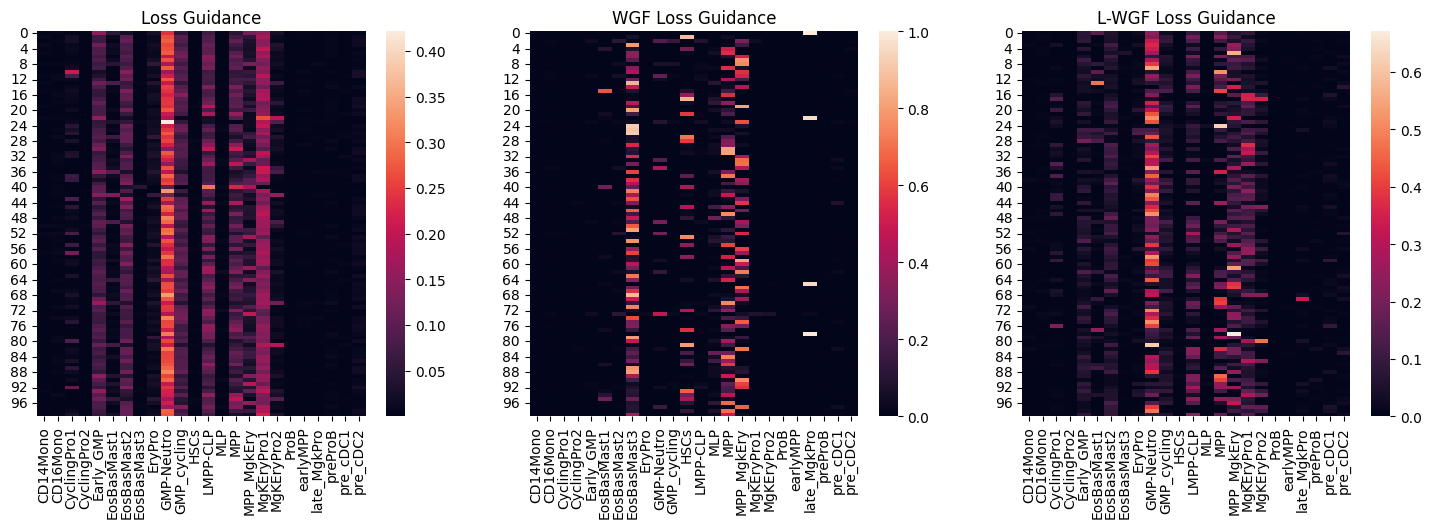

In [35]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

ax[0].set_title("Loss Guidance")
sns.heatmap(lgf_gen["ct_probs"].mean(0), ax=ax[0], xticklabels=ct_le.classes_)

ax[1].set_title("WGF Loss Guidance")
sns.heatmap(wgf_gen["ct_probs"].mean(0), ax=ax[1], xticklabels=ct_le.classes_)

ax[2].set_title("L-WGF Loss Guidance")
sns.heatmap(lwgf_gen["ct_probs"].mean(0), ax=ax[2], xticklabels=ct_le.classes_)